In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

HANDLING MISSING VALUES

In [7]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

FEATURE ENGINEERING

In [9]:
df["Age"] = 2026-df["Year_Birth"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [13]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Time"] = (reference_date - df["Dt_Customer"]).dt.days

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Time
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [16]:
df["Total_spendings"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Time,Total_spendings
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [18]:
df["Total_kids"] = df["Kidhome"] + df["Teenhome"]

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Time,Total_spendings,Total_kids
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [21]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [22]:
df["Education"] = df["Education"].replace({
    "Basic":"Undergradute","2n Cycle":"Undergradute",
    "Graduation":"Gradute",
    "Master":"Postgradute","PhD":"Postgradute",
})

In [23]:
df["Education"].value_counts()

Education
Gradute         1127
Postgradute      856
Undergradute     257
Name: count, dtype: int64

In [24]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [25]:
df["Living_status"] = df["Marital_Status"].replace({
    "Married":"WithPartner","Together":"WithPartner",
    "Widow":"WithoutPartner","YOLO":"WithoutPartner",
    "Alone":"WithoutPartner","Absurd":"WithoutPartner",
    "Single":"WithoutPartner","Divorced":"WithoutPartner",
})

In [26]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Time,Total_spendings,Total_kids,Living_status
0,5524,1957,Gradute,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,WithoutPartner
1,2174,1954,Gradute,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,WithoutPartner
2,4141,1965,Gradute,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,WithPartner
3,6182,1984,Gradute,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,WithPartner
4,5324,1981,Postgradute,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,WithPartner


In [28]:
df["Living_status"].value_counts()

Living_status
WithPartner       1444
WithoutPartner     796
Name: count, dtype: int64

In [29]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds","MntFruits"]
drop_cols = cols + spending_cols

df_cleanded = df.drop(columns = drop_cols)

In [30]:
df.shape

(2240, 27)

In [32]:
df_cleanded.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_Time',
       'Total_spendings', 'Total_kids', 'Living_status'],
      dtype='object')

In [31]:
df_cleanded.shape

(2240, 15)

In [33]:
cols = ["Income","Recency","Response","Age","Total_kids","Total_spendings"]

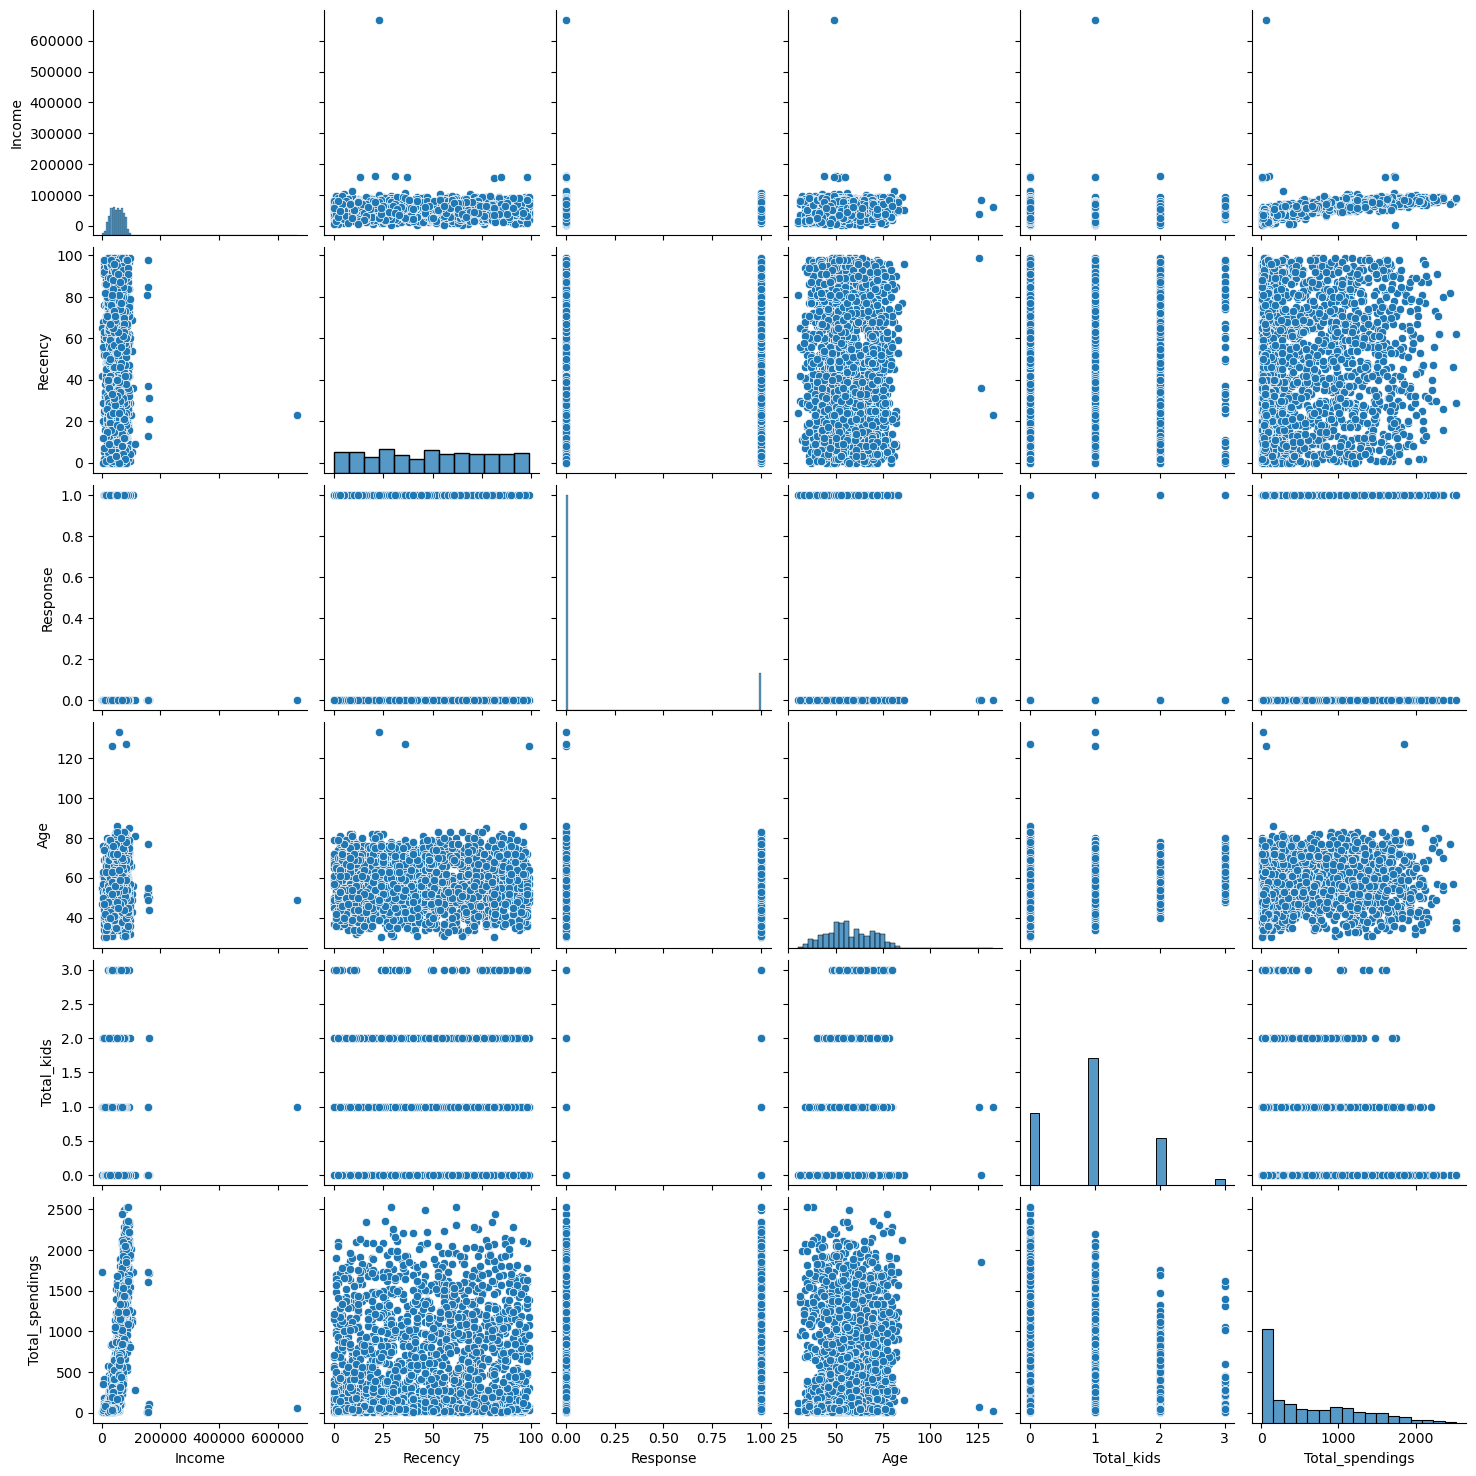

In [34]:
sns.pairplot(df_cleanded[cols])

In [35]:
print("data size with outliers:",len(df_cleanded))

df_cleanded = df_cleanded[(df_cleanded["Age"] < 90 )]
df_cleanded = df_cleanded[(df_cleanded["Income"]< 600_000)]

print("data size without outliers:",len(df_cleanded))

data size with outliers: 2240
data size without outliers: 2236


HEATMAP

In [37]:
corr = df_cleanded.corr(numeric_only=True)

<Axes: >

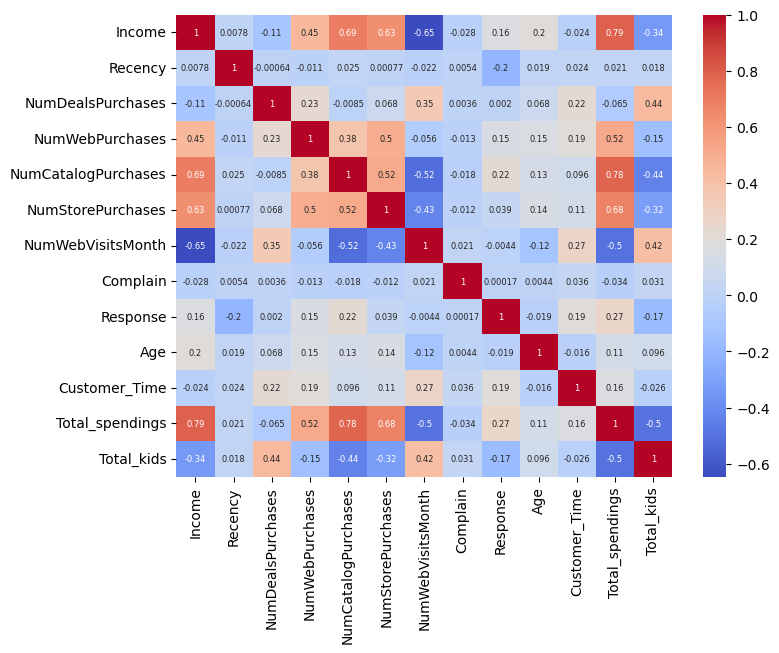

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

ENCODING

In [42]:
from sklearn.preprocessing import OneHotEncoder

In [43]:
ohe = OneHotEncoder()

In [44]:
df_cleanded.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Time,Total_spendings,Total_kids,Living_status
0,Gradute,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,WithoutPartner
1,Gradute,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,WithoutPartner
2,Gradute,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,WithPartner
3,Gradute,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,WithPartner
4,Postgradute,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,WithPartner


In [45]:
categorical_cols = ["Education","Living_status"]

In [47]:
encoded_cols = ohe.fit_transform(df_cleanded[categorical_cols])

In [48]:
encoded_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(categorical_cols),index = df_cleanded.index)

In [49]:
encoded_df.head()

,Education_Gradute,Education_Postgradute,Education_Undergradute,Living_status_WithPartner,Living_status_WithoutPartner
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0


In [50]:
df_encoded = pd.concat([df_cleanded.drop(columns=categorical_cols),encoded_df],axis=1)

In [52]:
df_encoded.shape

(2236, 18)

SCALING

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()

In [55]:
X = df_encoded

In [56]:
x_scaled = scaler.fit_transform(X)

In [57]:
from sklearn.decomposition import PCA

In [58]:
pca = PCA(n_components=3)

x_pca = pca.fit_transform(x_scaled)

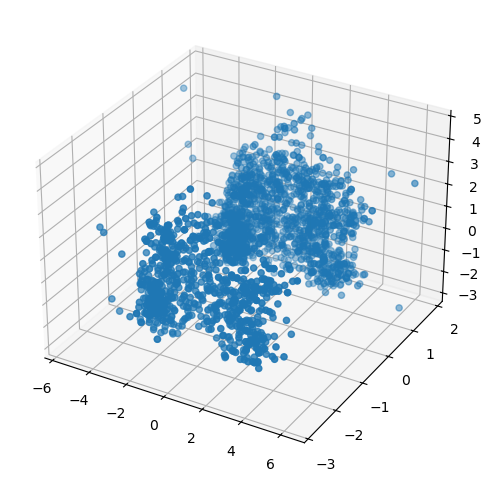

In [60]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ANALYZE K VALUE

In [67]:
# ELBOW METHOD
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [68]:
wcss =[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state = 42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [73]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

print("optimal k values is:",optimal_k)

optimal k values is: 4


Text(0, 0.5, 'wcss value')

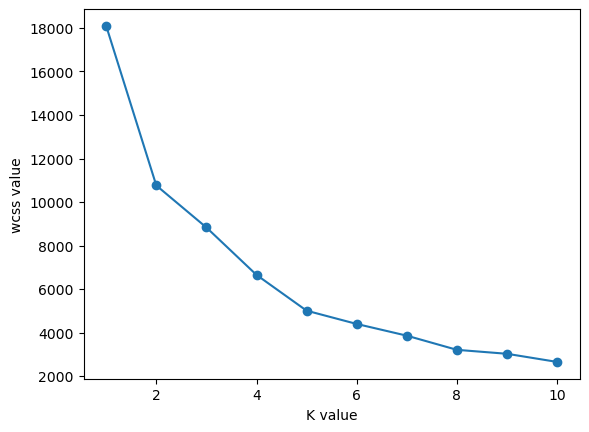

In [74]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K value")
plt.ylabel("wcss value")

SILHOUETTE SCORE

In [77]:
from sklearn.metrics import silhouette_score

Text(0, 0.5, 'silhouette score')

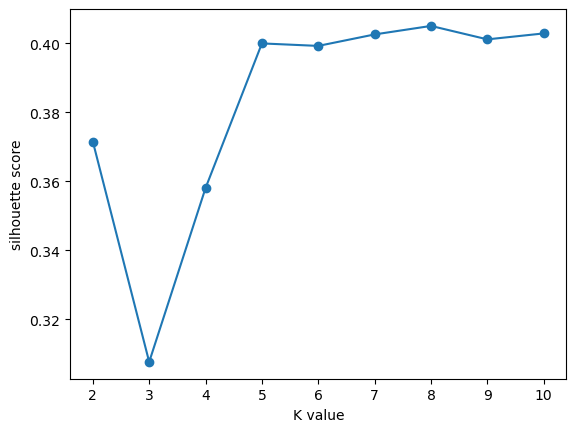

In [83]:
ss = []
for k in range(2,11):
    km = KMeans(n_clusters=k,random_state=42)
    labels = km.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    ss.append(score)



plt.plot(range(2,11),ss,marker='o')
plt.xlabel("K value")
plt.ylabel("silhouette score")
    

Text(0, 0.5, 'ss')

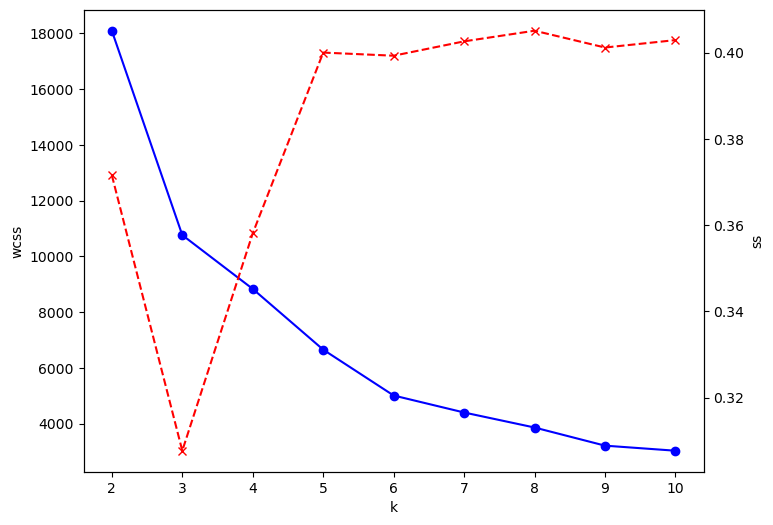

In [88]:
k_range = range(2,11)


fig , ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")


ax2 = ax1.twinx()

ax2.plot(k_range,ss[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("ss")

In [91]:
kmeans = KMeans(n_clusters=4,random_state=42)
kmeans_labels = kmeans.fit_predict(x_pca)

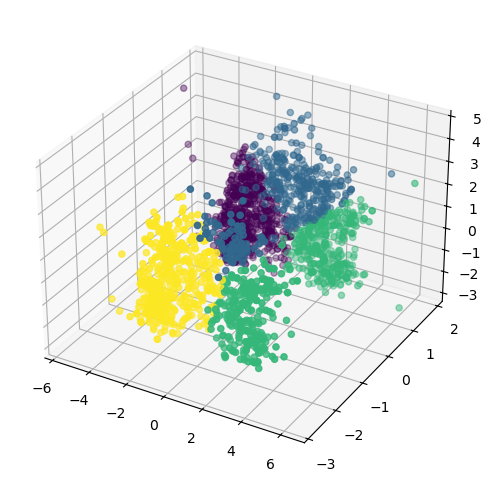

In [92]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=kmeans_labels)

In [94]:
from sklearn.cluster import AgglomerativeClustering

In [95]:
agg = AgglomerativeClustering(n_clusters=4,linkage="ward")
agg_labels = agg.fit_predict(x_pca)

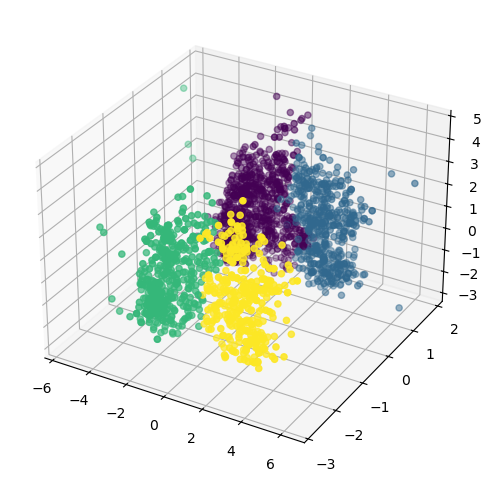

In [96]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=agg_labels)

In [99]:
df_encoded.drop("labels",axis=1)

df_encoded["cluster"] = agg_labels
df_encoded.tail()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Time,Total_spendings,Total_kids,Education_Gradute,Education_Postgradute,Education_Undergradute,Living_status_WithPartner,Living_status_WithoutPartner,labels,cluster
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,1.0,0.0,0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,1.0,0.0,0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,0.0,1.0,3,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,1.0,0.0,1,1
2239,52869.0,40,3,3,1,4,7,0,1,72,622,172,2,0.0,1.0,0.0,1.0,0.0,0,0


<Axes: xlabel='cluster', ylabel='count'>

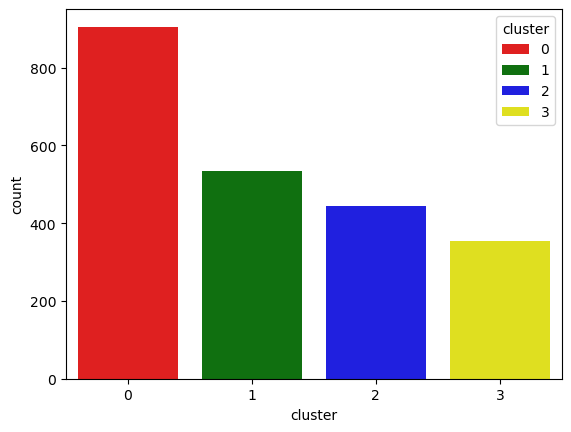

In [100]:
cls = ["red","green","blue","yellow"]

sns.countplot(x = df_encoded["cluster"],palette=cls, hue =  df_encoded["cluster"])

<Axes: xlabel='Total_spendings', ylabel='Income'>

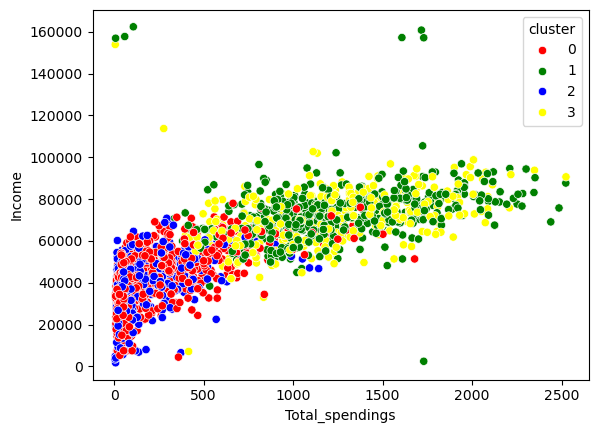

In [102]:
sns.scatterplot(x=df_encoded["Total_spendings"], y=df_encoded["Income"],hue = df_encoded["cluster"], palette=cls)